# H-005 · Vol-spike delever / flat

**Decides:** `SPIKE_MODE_STAR` — SPIKE_MODE_STAR (completes RISK_STAR)

Sleeve: **core**. Primary metric: **net** `ann_sharpe`. `psr` = P(true SR > 0). STAR is manual.


## 0. Imports & Config


In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s3_fx_trend.report import (
    fold_table,
    fold_val_metrics,
    full_is_metrics,
    load_star_stack,
    median_sharpe_hint,
    require_star,
    save_star_stack,
    update_star_stack_key,
)
from backtest.s3_fx_trend.research import (
    RESEARCH_IS_END_S3,
    config_from_stack,
    register_hypothesis_arms,
    star_stack_path,
)
from backtest.s3_fx_trend.runner import run_s3_backtest
from backtest.s3_fx_trend.walkforward import embargo_bars_for_config, make_s3_folds
from data.ingestion.fx_fetcher import G10_V1_PAIRS
from data.processing.s3_fx_price_panel import price_panel_path, s3_data_dir
from strategies.s3_fx_trend.config import S3SimConfig

DATA_DIR = s3_data_dir(ROOT)
ARTIFACTS = os.path.join(ROOT, "04_backtest", "s3_fx_trend", "artifacts")
os.makedirs(ARTIFACTS, exist_ok=True)
TEARSHEET_DIR = ARTIFACTS
SLEEVE = "core"
HYP_ID = "H-005"
print("ROOT=", ROOT)
print("DATA_DIR=", DATA_DIR)
print("RESEARCH_IS_END_S3=", RESEARCH_IS_END_S3)


ROOT= c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio
DATA_DIR= c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s3_fx_trend
RESEARCH_IS_END_S3= 2019-12-31 00:00:00


## 1. Load STAR stack


In [2]:
STACK_PATH = star_stack_path(SLEEVE)
stack = load_star_stack(STACK_PATH)
print("STAR stack path:", STACK_PATH)
print("Loaded keys with values:", {k: v for k, v in stack.items() if v is not None})
base_cfg = config_from_stack(stack)
print(base_cfg)


STAR stack path: C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s3_fx_trend\artifacts\s3_core_star_stack.json
Loaded keys with values: {'PAIR_VT_STAR': 'pair_vt', 'BOOK_VT_STAR': 'pair_plus_book_vt', 'HORIZON_STAR': '3M'}
S3SimConfig(pairs=('EURUSD', 'USDJPY', 'GBPUSD', 'USDCHF', 'USDCAD', 'AUDUSD', 'NZDUSD'), bar='1d', day_boundary_tz='America/New_York', day_boundary_hour=17, signal_family='tsmom', tsmom_lookbacks=(21, 63, 252), tsmom_blend='single_3m', donchian_n=55, donchian_hl_source='daily_ny_close', pair_vt=True, book_vt=True, vt_target_ann_vol=0.1, conviction_scaling='sign', weak_signal_flat_z=0.0, rebalance_band=0.0, carry_mode='off', carry_refresh='weekly', value_mode='off', value_refresh='monthly', carry_agree_scale=1.25, carry_disagree_scale=0.75, value_agree_scale=1.25, value_disagree_scale=0.75, spike_mode='off', spike_threshold_sigmas=2.0, corr_conflict_mode='off', corr_gate_threshold=0.85, currency_cap_gross_pct=0.5, cost_profile=

## 2. Data load (research panels)


In [3]:
def _read_parquet(path: str) -> pd.DataFrame:
    if not os.path.isfile(path):
        warnings.warn(f"missing panel: {path}")
        return pd.DataFrame()
    df = pd.read_parquet(path)
    if df.empty:
        warnings.warn(f"empty panel: {path}")
        return df
    if "date" in df.columns:
        df = df.copy()
        df["date"] = pd.to_datetime(df["date"])
    return df

price_path = price_panel_path("1d", data_dir=DATA_DIR)
panel = _read_parquet(price_path)
rates = _read_parquet(os.path.join(DATA_DIR, "g10_policy_rates.parquet"))
reer = _read_parquet(os.path.join(DATA_DIR, "bis_reer_monthly.parquet"))

if not panel.empty:
    is_mask = panel["date"] <= pd.Timestamp(RESEARCH_IS_END_S3)
    panel_is = panel.loc[is_mask].copy()
    panel_oos = panel.loc[~is_mask].copy()
else:
    panel_is = panel.copy()
    panel_oos = panel.copy()

print("price rows:", len(panel), "IS:", len(panel_is), "OOS:", len(panel_oos))
print("rates rows:", len(rates), "reer rows:", len(reer))

s1_weekly = None
s2_daily = None
for cand in (
    os.path.join(ROOT, "01_data", "data_files", "s1_equities", "s1_period_returns.parquet"),
    os.path.join(ROOT, "04_backtest", "s1_equities", "artifacts", "s1_period_returns.parquet"),
):
    if os.path.isfile(cand):
        s1 = pd.read_parquet(cand)
        # best-effort: first numeric column as weekly series
        if "date" in s1.columns:
            s1 = s1.set_index(pd.to_datetime(s1["date"]))
        num = s1.select_dtypes(include=[np.number])
        if not num.empty:
            s1_weekly = num.iloc[:, 0]
        break


price rows: 39337 IS: 27096 OOS: 12241
rates rows: 7207 reer rows: 235


## 3. Arms (pre-register)


In [4]:
configs = {
    "off": config_from_stack(stack, hyp_overrides={"spike_mode": "off"}),
    "pair_delever": config_from_stack(stack, hyp_overrides={"spike_mode": "pair_delever"}),
    "book_delever": config_from_stack(stack, hyp_overrides={"spike_mode": "book_delever"}),
    "both": config_from_stack(stack, hyp_overrides={"spike_mode": "both"}),
}
register_hypothesis_arms(HYP_ID, list(configs.keys()), sleeve=SLEEVE, overwrite=True)
print("registered", list(configs.keys()))


registered ['off', 'pair_delever', 'book_delever', 'both']


## 4. Fold-val + boxplots

Boxplots use **net** Sharpe and max DD (shown inline). Full-IS is computed here; the locked metrics table is shown in §5.


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,2007-01-01,2009-10-30,989,2009-10-31,2009-11-04,2009-11-05,2012-08-12,994
1,2,2007-01-01,2012-08-06,1983,2012-08-07,2012-08-12,2012-08-13,2016-04-14,994
2,3,2007-01-01,2016-04-07,2977,2016-04-10,2016-04-14,2016-04-17,2019-12-30,995


,arm,fold_id,ann_sharpe,ann_sharpe_gross,max_drawdown,calmar,corr_to_s1,corr_to_s2,psr,dsr_local,dsr_stack,skew,excess_kurtosis,cost_bps_per_year,n_days,n_entries,n_trials_local,n_trials_stack
0,off,1,-0.031167,0.055371,-0.183167,-0.049832,NaN,NaN,1.621044e-01,2.052490e-02,2.845775e-03,-0.363461,5.337782,176.468037,992,330,4,15
1,off,2,0.238574,0.413955,-0.126712,0.159185,0.187194,NaN,1.000000e+00,1.000000e+00,1.000000e+00,0.285787,5.575532,235.939898,992,373,4,15
2,off,3,-0.142368,0.016915,-0.161756,-0.124976,0.015571,NaN,2.947465e-06,1.115501e-08,1.316230e-10,-0.325897,3.160800,282.639023,993,427,4,15
3,pair_delever,1,0.382250,0.491059,-0.152399,0.229664,NaN,NaN,1.000000e+00,1.000000e+00,1.000000e+00,0.032329,1.917946,176.468037,992,330,4,15
4,pair_delever,2,0.206868,0.421205,-0.133007,0.122703,0.228999,NaN,1.000000e+00,1.000000e+00,9.999987e-01,0.077552,1.256234,235.939898,992,373,4,15
5,pair_delever,3,-0.221605,-0.033758,-0.165295,-0.165547,-0.001836,NaN,2.637057e-12,1.054712e-15,0.000000e+00,-0.036008,0.590663,282.639023,993,427,4,15
6,book_delever,1,-0.010129,0.098737,-0.133544,-0.030719,NaN,NaN,3.748482e-01,8.506727e-02,1.827531e-02,-0.120541,0.504436,176.468037,992,330,4,15
7,book_delever,2,0.067221,0.283685,-0.141563,0.014975,0.282270,NaN,9.826429e-01,8.558294e-01,6.348472e-01,-0.024637,0.271845,235.939898,992,373,4,15
8,book_delever,3,-0.177527,0.015332,-0.152131,-0.120121,0.027789,NaN,1.151234e-08,1.579187e-11,9.398038e-14,-0.072158,-0.200610,282.639023,993,427,4,15
9,both,1,0.419100,0.545803,-0.128257,0.254600,NaN,NaN,1.000000e+00,1.000000e+00,1.000000e+00,0.050352,0.120445,176.468037,992,330,4,15


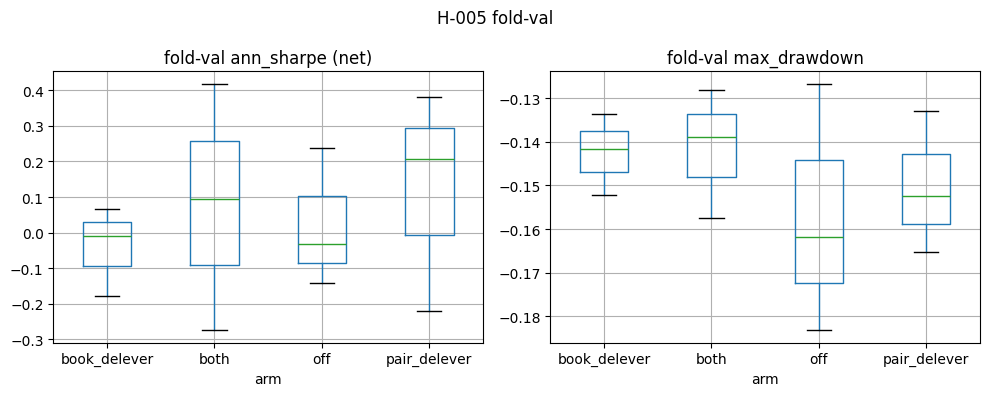

median_sharpe_hint (commentary only): pair_delever


In [5]:
FULL_IS_COLS = [
    "arm",
    "ann_sharpe",
    "ann_sharpe_gross",
    "max_drawdown",
    "corr_to_s1",
    "corr_to_s2",
    "calmar",
    "psr",
    "dsr_local",
    "dsr_stack",
    "skew",
    "excess_kurtosis",
    "cost_bps_per_year",
    "n_days",
    "n_entries",
]

fold_df = pd.DataFrame()
full_is_df = pd.DataFrame()
_reer = reer if "reer" in dir() else pd.DataFrame()

if panel_is.empty or "date" not in panel_is.columns:
    print("SKIP fold-val / full-IS: research IS price panel missing or empty.")
    print("Run 01_data/data_files/s3_fx_trend/s3_research_panels.ipynb first.")
else:
    is_dates = pd.DatetimeIndex(panel_is["date"].drop_duplicates().sort_values())
    try:
        folds = make_s3_folds(
            is_dates,
            n_folds=3,
            embargo_bars=embargo_bars_for_config(bar=getattr(base_cfg, "bar", "1d")),
        )
        display(fold_table(folds))
        fold_df = fold_val_metrics(
            panel_is,
            folds,
            configs,
            hyp_id=HYP_ID,
            sleeve=SLEEVE,
            s1_weekly=s1_weekly,
            s2_daily=s2_daily,
            rates_df=rates if not rates.empty else None,
            reer_df=_reer if not _reer.empty else None,
        )
        display(fold_df.head(20))

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        if not fold_df.empty and "ann_sharpe" in fold_df.columns:
            fold_df.boxplot(column="ann_sharpe", by="arm", ax=axes[0])
            axes[0].set_title("fold-val ann_sharpe (net)")
            axes[0].set_xlabel("arm")
        if not fold_df.empty and "max_drawdown" in fold_df.columns:
            fold_df.boxplot(column="max_drawdown", by="arm", ax=axes[1])
            axes[1].set_title("fold-val max_drawdown")
            axes[1].set_xlabel("arm")
        plt.suptitle(f"{HYP_ID} fold-val")
        plt.tight_layout()
        plt.show()

        full_is_df = full_is_metrics(
            panel_is,
            configs,
            hyp_id=HYP_ID,
            sleeve=SLEEVE,
            s1_weekly=s1_weekly,
            s2_daily=s2_daily,
            rates_df=rates if not rates.empty else None,
            reer_df=_reer if not _reer.empty else None,
        )
        hint = median_sharpe_hint(fold_df)
        print("median_sharpe_hint (commentary only):", hint)
    except Exception as exc:
        warnings.warn(f"fold-val / full-IS failed (panel may be too short): {exc!r}")


## 5. Full-IS metrics table

Locked columns: `ann_sharpe`, `ann_sharpe_gross`, `max_drawdown`, `corr_to_s1`, `corr_to_s2`, `calmar`, `psr`, `dsr_local`, `dsr_stack`, `skew`, `excess_kurtosis`, `cost_bps_per_year`, `n_days`, `n_entries`.


In [6]:
display(full_is_df[[c for c in FULL_IS_COLS if c in full_is_df.columns]]) if not full_is_df.empty else print('no full-IS yet')


,arm,ann_sharpe,ann_sharpe_gross,max_drawdown,corr_to_s1,corr_to_s2,calmar,psr,dsr_local,dsr_stack,skew,excess_kurtosis,cost_bps_per_year,n_days,n_entries
0,off,0.190325,0.331589,-0.202340,0.044804,NaN,0.073571,1.0,1.0,1.0,-0.145362,4.824577,204.816978,3975,1406
1,pair_delever,0.314167,0.486138,-0.201316,0.038517,NaN,0.138733,1.0,1.0,1.0,0.025327,1.309737,204.816978,3975,1406
2,book_delever,0.197564,0.370464,-0.193747,0.077814,NaN,0.067696,1.0,1.0,1.0,-0.065771,0.258733,204.816978,3975,1406
3,both,0.305672,0.501720,-0.173908,0.064766,NaN,0.133968,1.0,1.0,1.0,0.008947,-0.157788,204.816978,3975,1406


## 6. Freeze STAR (manual)


In [8]:
# MANUAL STAR freeze — edit the value, then run. Do not auto-assign from hint.
# STAR_KEY = "SPIKE_MODE_STAR"
# STAR_VALUE = None  # e.g. "both"

STAR_KEY = "SPIKE_MODE_STAR"
STAR_VALUE = "both"  # <-- set manually after reviewing fold-val / full-IS

if STAR_VALUE is None:
    print(f"STAR_VALUE is None — leave unset until you decide. stack[{STAR_KEY!r}] stays as-is.")
else:
    update_star_stack_key(STACK_PATH, STAR_KEY, STAR_VALUE)
    stack = load_star_stack(STACK_PATH)
    require_star(STAR_KEY, stack.get(STAR_KEY))
    print("Froze", STAR_KEY, "=", stack.get(STAR_KEY))


Froze SPIKE_MODE_STAR = both
